# 23회차 기출문제 해답

## 문제 1

**Data description**

-   temperature : 온도(섭씨)

-   Humidity : 습도(%)

-   Light : 밝기(lux)

-   Co2 : 이산화탄소 농도(ppm)

-   Occupancy : 방 이용 유무

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [2]:
dat = pd.read_csv('problem1.csv')

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  300 non-null    float64
 1   humidity     300 non-null    float64
 2   light        300 non-null    float64
 3   co2          295 non-null    float64
 4   occupancy    300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


**1. 데이터를 탐색하고 탐색 결과를 제시하시오.**

In [4]:
dat.isna().sum()

temperature    0
humidity       0
light          0
co2            5
occupancy      0
dtype: int64

co2 컬럼에 결측치가 5개 존재한다.   
방이용 유무는 명목형 이진변수로 object 형으로 변환해준다. 

In [5]:
dat['occupancy'] = dat['occupancy'].astype('O')

In [6]:
dat.head()

,temperature,humidity,light,co2,occupancy
0,23.745,25.3900,779.0,710.00,1
1,19.890,35.5000,0.0,519.00,0
2,23.625,25.4175,779.0,715.50,1
3,22.100,26.0750,489.5,1003.25,1
4,21.236,25.3300,471.0,774.00,1


<<연속형 변수>>


,count,mean,std,min,25%,50%,75%,max
temperature,300.0,21.780052,0.950689,19.2,21.29000,21.79000,22.200000,24.3900
humidity,300.0,28.181973,4.459320,17.6,25.21125,27.94375,31.260000,39.0675
light,300.0,424.539667,180.400411,0.0,428.25000,444.00000,472.333333,1380.0000
co2,295.0,927.995876,323.542741,418.0,696.97500,891.25000,1069.375000,2022.5000


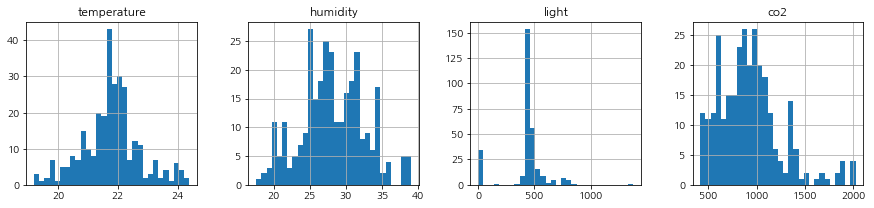

<<명목형 변수>>


,count,unique,top,freq
occupancy,300,2,1,264


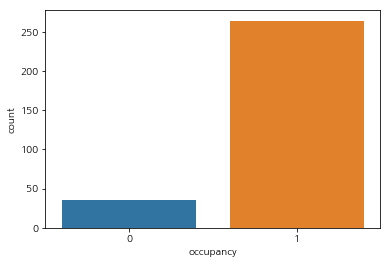

In [7]:
cat_cols = dat.select_dtypes('O').columns
num_cols = dat.select_dtypes('number').columns

print("<<연속형 변수>>")
display(dat[num_cols].describe().T)
dat[num_cols].hist(figsize=(15, 3), bins=30, layout=(1, 4))
plt.show()

print("<<명목형 변수>>")
display(dat[cat_cols].describe().T)
sns.countplot(data=dat[cat_cols], x=cat_cols.values[0])
plt.show()

- light: 이봉분포
- Co2: 우측 긴꼬리 분포로 로그변환 고려
- 방 이용유무: 방 이용 경우가 압도적으로 비율높음(불균형 데이터, 88:22)

<<연속형 변수 이상치 확인>>


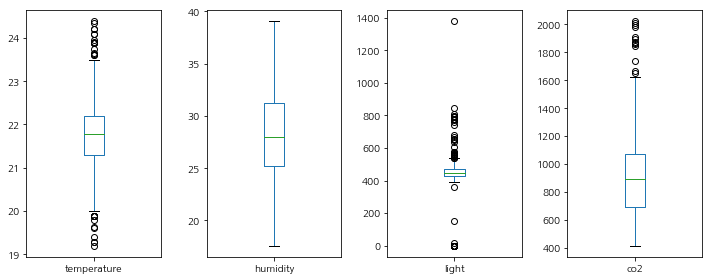

In [8]:
print("<<연속형 변수 이상치 확인>>")
dat[num_cols].plot(kind='box', subplots=True, layout=(1, 4), figsize=(10, 4))
plt.tight_layout()
plt.show()

boxplot으로 사분위수 기준 이상치 의심 point를 식별할 수 있으나,  
데이터 기반지식이 없으므로 삭제하지 않는다.  
(범위 바깥의 데이터가 의미있을 수 있음)

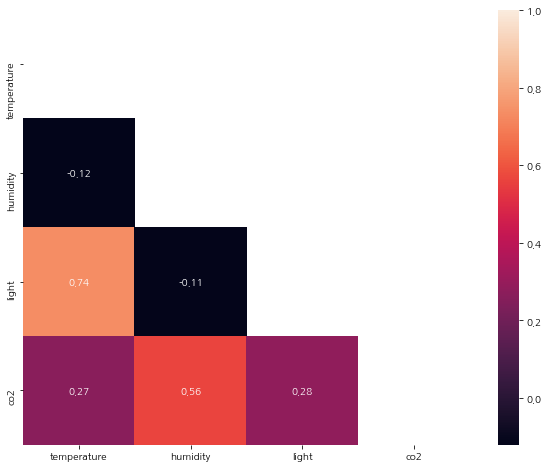

In [9]:
plt.figure(figsize=(10, 8))
corr = dat.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

각 변수들 간 1:1 선형 상관관계 분석을 위해 피어슨 상관관계 분석 수행  
온도와 광원 사이 0.74로 비교적 높은 양의 상관관계 관찰됨  
습도와 이산화탄소 간에도 0.56으로 양의 상관관계가 관찰됨

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = num_cols
vif['vif'] = [variance_inflation_factor(dat[num_cols].dropna().values, i) 
              for i in range(len(num_cols))]
display(vif[1:])

,name,vif
1,humidity,62.453660
2,light,10.649184
3,co2,16.162638


vif 검정결과 모두 10 이상으로 다중조합형 공선성이 관찰되었다.  
추후 다중공선성 문제 해결을 위한 pca, 변수 제거 등의 방법이 필요하겠다.   
(분포 왜도 완화(log) 후 다시 확인필요)

**2. 결측치를 탐색하고, 결측치 대치 방법 한 가지를 수행하고, 해당 방법을 사용한 근거를 제시하시오.**

In [11]:
dat[dat['co2'].isna()]

,temperature,humidity,light,co2,occupancy
58,20.6000,22.6000,0.00,NaN,0
63,19.8900,35.4000,0.00,NaN,0
162,23.2225,25.9175,653.75,NaN,1
214,21.0000,24.7000,0.00,NaN,0
250,24.1000,26.4725,775.75,NaN,1


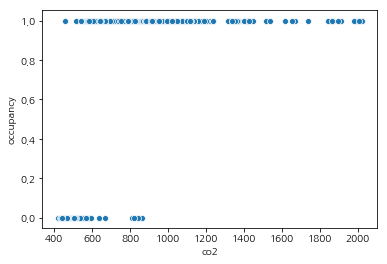

In [12]:
sns.scatterplot(data=dat, x='co2', y='occupancy')
plt.show()

co2값의 결측치는 5개로 총 데이터의 약 1.67%를 차지하며, 그 비율이 낮다.   
데이터에 대한 사전지식이 없으며, 다른 변수를 통한 추론으로 적절한 값으로 대체할 수 없으므로(종속변수 class별 분포도 넓음),    
대푯값을 통한 결측치 보간 시 데이터의 오류가 커질 수 있다. 
따라서 대치하지 않고 제거한다. 

In [13]:
print(f"결측치 처리 전 데이터 수: {len(dat)}")
dat = dat.dropna()
print(f"결측치 처리 후 데이터 수: {len(dat)}")

결측치 처리 전 데이터 수: 300
결측치 처리 후 데이터 수: 295


**3. 추가적으로 데이터 질을 향상시킬만한 내용을 작성하시오(구현 안하고 설명만해도 됨).**


1. 분포왜도 완화를 위해 양의 왜도인 Co2의 로그화
2. 분포왜도 완화 후 다중공선성이 지속적으로 존재한다면 다중공선성 제거를 위한  
   차원축소(PCA) 수행
3. 스케일링(standard) 적용을 통한 범위 표준화

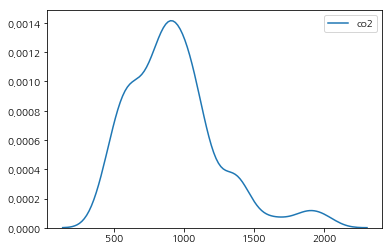

,name,vif
1,humidity,62.453660
2,light,10.649184
3,co2,16.162638


In [14]:
# 로그화
# dat['co2'] = np.log(dat['co2'])
sns.kdeplot(dat['co2'])
plt.show()

#다중공선성 다시 확인
vif = pd.DataFrame()
vif['name'] = num_cols
vif['vif'] = [variance_inflation_factor(dat[num_cols].dropna().values, i) 
              for i in range(len(num_cols))]
display(vif[1:])

다중공선성이 완화되지 않았으므로 추후 PCA를 실시한다.

**4. 데이터 불균형을 식별하고 불균형을 처리할 오버샘플링 기법 두 가지를 제시하시오.**



앞서 종속변수인 occupancy 변수의 비가 88:22 정도로 불균형함을 알 수 있었다.  
불균형 처리없이 모델학습을 한다면 minority class의 예측을 잘 하지 못하는 문제가 있기 때문에   
minor calss 의 데이터수를 증강해주는 오버샘플링 기법을 적용한다.  

1. Random Oversampling: 소수 클래스 샘플을 단순 복제 
    비교군으로 사용한다. 
2. KMeans SMOTE: 비지도학습인 KMeans로 클러스터링 후 클러스터 내에서 SMOTE 적용

**5. 오버샘플링한 데이터셋을 각각 제시하고, 오버샘플링 기법별 장·단점을 작성하시오.**

1. Random Oversampling: 구현이 간단하며 빠른 장점이 있지만, 과적합 가능성이 존재한다.  
2. KMeans SMOTE: 노이즈가 적으며 효과적 샘플링이 가능하나, 복잡도가 높고, 파라미터가 많은 단점이 있다. 

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler, KMeansSMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from collections import Counter

Y = dat['occupancy'].astype('int64')#숫자로 변형
X = dat.drop(columns='occupancy')

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

n_cols = X.columns
p_pro = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.85))]), n_cols),
    remainder='passthrough'
)

#오버샘플링을 위한 파이프라인
ov1 = Pipeline([
    ('preprocessor', p_pro), 
    ('over', RandomOverSampler(random_state=42))
])

ov2 = Pipeline([
    ('preprocessor', p_pro), 
    ('over', KMeansSMOTE(random_state=42, k_neighbors=3))
])

train_X_1, train_Y_1 = ov1.fit_resample(train_X, train_Y)
train_X_2, train_Y_2 = ov2.fit_resample(train_X, train_Y)

print(f"랜덤오버샘플링: {Counter(train_Y_1)}")
print(f"Kmeans SMOTE: {Counter(train_Y_2)}")

랜덤오버샘플링: Counter({1: 196, 0: 196})
Kmeans SMOTE: Counter({0: 197, 1: 196})


In [29]:
train_X_1.shape

(392, 3)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(train_X_1, train_Y_1)
print("랜덤오버샘플링: ", model.score(train_X_1, train_Y_1))
model.fit(train_X_2, train_Y_2)
print("Kmeans SMOTE: ", model.score(train_X_2, train_Y_2))

랜덤오버샘플링:  0.9719387755102041
Kmeans SMOTE:  0.9923664122137404


두 오버샘플링 기법 모두 두 클래스가 균일하게 오버샘플링 된 것을 확인할 수 있다.  
앞서 EDA 시 다중공선성 문제가 있어, 스케일링 후 PCA를 적용하여 원본 데이터 분산설명력의 85% 수준을 설명하는 3개의 주성분 축으로 재생성하였다. 

간단하게 로지스틱 회귀모델을 통해 학습데이터 성능을 판단했을 때   
kmeans SMOTE의 성능이 더 뛰어남(0.992)을 알 수 있다. 

**6. 오버샘플링 데이터셋을 이용해서 정확도 측면 모형과 속도 측면 모형을 각각 제시하시오.**  
- 정확도 측면: 랜덤포레스트 모델
   배깅기반 앙상블 모델로 과적합 억제, 간편한 사용, 다양한 데이터에 강건한 특징을 가지고 있으나, 대규모 데이터 학습 시 비용이 높음
- 속도 측면 모형: 로지스틱 회귀
  선형모델방식을 기반으로 하는 이진분류 모델로 빠른 학습속도와 높은 해석성이 장점이나, 복잡한 비선형 패턴 학습이 불가하며, 독립변수 간 독립성, 정규성 만족 및 다중공선성이 없어야 하는 제약조건이 있다.
  
- 학습시간 측정을 통해 속도를 확인하고, macro accuracy, f1_score(조화평균)을 통해 예측성능을 확인한다. 



In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

lr = Pipeline([
    ('preprocessor', p_pro), 
    ('smote', KMeansSMOTE(random_state=42, k_neighbors=3)), 
    ('classifier', LogisticRegression(random_state=42))
])

rf = Pipeline([
    ('preprocessor', p_pro), 
    ('smote', KMeansSMOTE(random_state=42, k_neighbors=3)), 
    ('classifier', RandomForestClassifier(random_state=42))
])

model_list = [('로지스틱 회귀', lr), ("랜덤포레스트classifer", rf)]
dt_list = [('학습데이터', train_X, train_Y), ('테스트데이터', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'acc', 'f1', 'time'])

for m_name, model in model_list:
    start = time.time()
    model.fit(train_X, train_Y)
    end = time.time()
    t_time = end - start
    print(f"<<{m_name}>>")
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, acc, f1, t_time]
        print(f"- 데이터셋: {d_name}")
        print(classification_report(y, pred))
display(rs)

<<로지스틱 회귀>>
- 데이터셋: 학습데이터
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        25
           1       0.99      0.99      0.99       196

    accuracy                           0.99       221
   macro avg       0.96      0.97      0.97       221
weighted avg       0.99      0.99      0.99       221

- 데이터셋: 테스트데이터
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.98      0.99        66

    accuracy                           0.99        74
   macro avg       0.94      0.99      0.97        74
weighted avg       0.99      0.99      0.99        74

<<랜덤포레스트classifer>>
- 데이터셋: 학습데이터
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00       196

    accuracy                           1.00       221
   macro avg       1.00      1.00      1.00       221

,name,data,acc,f1,time
0,로지스틱 회귀,학습데이터,0.986425,0.992327,0.046010
1,로지스틱 회귀,테스트데이터,0.986486,0.992366,0.046010
2,랜덤포레스트classifer,학습데이터,1.000000,1.000000,0.148318
3,랜덤포레스트classifer,테스트데이터,0.986486,0.992366,0.148318


**7. 둘 중 하나의 모형을 선택하고 분류 결과와 함께 이유를 제시하시오.**

두 모형 모두 과적합 없이 높은 예측성능을 보여주었다.  
테스트셋 기준 예측성능은 두 모델 모두 동일하므로 
(accuracy: 0.986486 / f1: 0.992366)   
학습속도가 더 빠른 로지스틱 회귀를 채택한다. 

**8. 원데이터와 비교해서 오버샘플링이 미친 영향에 대해 작성하시오.**

In [36]:
lr2 = Pipeline([
    ('preprocessor', p_pro), 
    ('classifier', LogisticRegression(random_state=42))
])

rs = pd.DataFrame(columns=['name', 'data', 'acc', 'f1', 'time'])


lr2.fit(train_X, train_Y)
print(f"<<원본데이터>>")
for d_name, x, y in dt_list:
    pred = lr2.predict(x)
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred)
    rs.loc[len(rs)] = ['원본', d_name, acc, f1, t_time]
    print(f"- 데이터셋: 로지스틱회귀(원본)")
    print(classification_report(y, pred))
display(rs)

<<원본데이터>>
- 데이터셋: 로지스틱회귀(원본)
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.99      1.00      1.00       196

    accuracy                           1.00       221
   macro avg       1.00      0.98      0.99       221
weighted avg       1.00      1.00      1.00       221

- 데이터셋: 로지스틱회귀(원본)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.98      0.99        66

    accuracy                           0.99        74
   macro avg       0.94      0.99      0.97        74
weighted avg       0.99      0.99      0.99        74



,name,data,acc,f1,time
0,원본,학습데이터,0.995475,0.997455,0.148318
1,원본,테스트데이터,0.986486,0.992366,0.148318


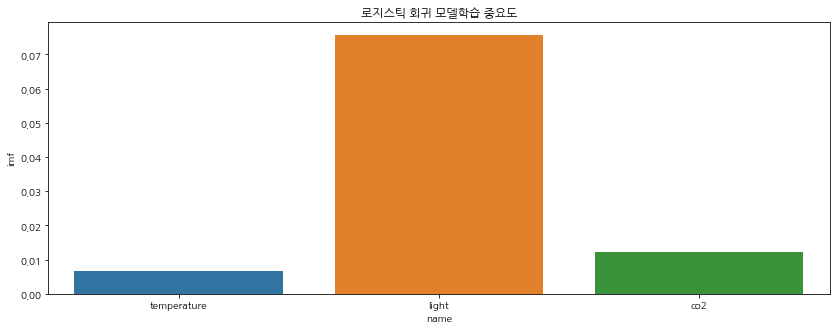

In [40]:
from sklearn.inspection import permutation_importance

f_imp = permutation_importance(lr2, test_X, test_Y, n_repeats=10, random_state=42)
feat = train_X.columns
f_imf_df = pd.DataFrame({'name':feat, 
                         'imf': f_imp.importances_mean})
f_imf_df = f_imf_df.loc[f_imf_df['imf']>0]
#시각화
plt.figure(figsize=(14, 5))
sns.barplot(data=f_imf_df, x='name', y='imf')
plt.title('로지스틱 회귀 모델학습 중요도')
plt.show()

오버샘플링과 원데이터의 학습성능 차이가 없었다.  
Permutation Importance를 통해 확인한 모델학습 간 설명변수 기여도를 보면, 
light 변수가 압도적으로 모델 성능에 기여하는 것을 알 수 있으며,  
이는 데이터가 불균형함에도 불구하고, 종속변수를 분류해 낼 수 있는 뚜렷한 특징을  해당변수가 가지고 있음을 추측할 수 있다.

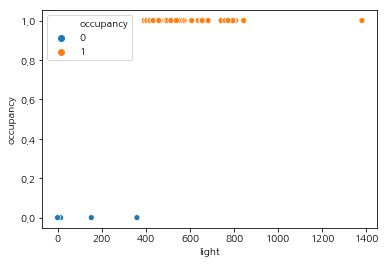

In [48]:
sns.scatterplot(data=dat,x='light',y='occupancy', hue='occupancy')
plt.show()

## 문제 2

**1. ACF를 활용하여 distance를 계산하시오.**

::: callout-note
문제의 의도는 시계열 자료의 특성을 반영한 거리를 구하는 것입니다. 단순 유클리디안 거리의 경우 시계열 특성을 반영할 수 없으므로, ACF를 통해 시계열 특성을 반영한 후 유클리디안 거리를 계산합니다.

$$
\text{ACF distance}(X, Y) = \sqrt{\sum_{k=1}^{L} \left( \rho_X(k) - \rho_Y(k) \right)^2}
$$

-   $L$ 은 ACF를 계산할 최대 시차(lag)의 개수입니다.
-   $\rho_X(k)$ 는 시계열 X 에 대해 시차 k 에서의 ACF 값입니다.
-   $\rho_Y(k)$ 는 시계열 Y 에 대해 시차 k 에서의 ACF 값입니다.
:::

In [74]:
df = pd.read_csv("problem2.csv")
df.head()

,country,date,confirmed
0,Belarus,2020-01-22,0
1,Belarus,2020-01-23,0
2,Belarus,2020-01-24,0
3,Belarus,2020-01-25,0
4,Belarus,2020-01-26,0


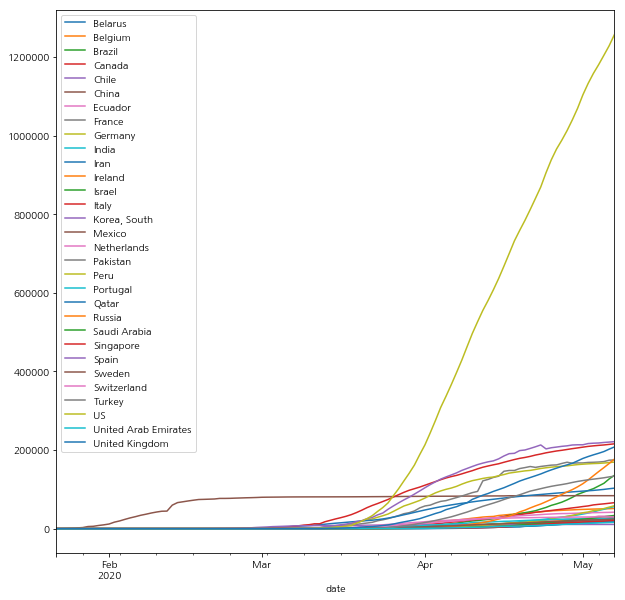

In [75]:
df['date']=pd.to_datetime(df['date'])
dat = df.pivot(index='date', columns='country', values='confirmed')
dat.plot(figsize=(10, 10));
plt.legend(loc='upper left', prop={'size': 10});
plt.show();

미국의 경우 100만명 이상의 누적확진자 존재함.
정상성 여부 확인을 위해 adf 검정 실시

In [76]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.graphics.tsaplots import acf

rs = adfuller(df['confirmed'])

print(f"유의수준 5% 하 통계량: {rs[0]:.3f} / p-value: {rs[1]:.3f}")

유의수준 5% 하 통계량: 1.569 / p-value: 0.998


adfuller 결과 정상성을 만족하지 않으므로 차분 수행,  
이후 acf 계산, acf는 두 시계열의 자기상관 패턴 간의 차이를 수치화한 값으로  
시계열의 구조적 유사성을 평가하는 지표임

In [77]:
df['diff'] = df['confirmed'].diff(1)
rs = adfuller(df['diff'].dropna())

print(f"유의수준 5% 하 통계량: {rs[0]:.3f} / p-value: {rs[1]:.3f}")

유의수준 5% 하 통계량: -9.255 / p-value: 0.000


In [78]:
df.drop(columns='confirmed', inplace=True)

In [80]:
df['country'].nunique()

31

In [79]:
from scipy.spatial.distance import pdist, squareform

# 1) 국가별로 그룹화 후 ACF 벡터 계산
acf_dict = {}
nlags = 40  # 최대 lag 수

for country, sub in df.groupby('country'):
    # 1-1) 차분 시계열(이미 diff 컬럼)에서 NaN 제거
    diff_ts = sub.set_index('date')['diff'].dropna()
    
    # 1-2) ACF 계산
    acf_vals = acf(diff_ts, nlags=nlags, fft=False)[1:] # lag 0은 자기 자신이므로 빼줌
    acf_dict[country] = acf_vals

# 2) ACF 벡터를 쌓아 거리 계산
countries = list(acf_dict.keys())
acf_matrix = np.vstack([acf_dict[c] for c in countries])

# 2-1) 유클리디안 거리 행렬 생성
dist_array = pdist(acf_matrix, metric='euclidean')
dist_matrix = squareform(dist_array)

# 3) 결과를 DataFrame으로 정리
dist_df = pd.DataFrame(dist_matrix, index=countries, columns=countries)

print("차분(diff) 후 ACF 기반 국가 간 거리 행렬:")
display(dist_df)

차분(diff) 후 ACF 기반 국가 간 거리 행렬:


,Belarus,Belgium,Brazil,Canada,Chile,China,Ecuador,France,Germany,India,...,Russia,Saudi Arabia,Singapore,Spain,Sweden,Switzerland,Turkey,US,United Arab Emirates,United Kingdom
Belarus,0.000000,2.189609,2.095709,2.489316,2.499395,2.268868,2.499378,1.823195,2.440600,2.500387,...,0.701512,2.508918,2.471347,0.974940,2.512495,2.402805,1.662680,1.427984,2.512116,0.712807
Belgium,2.189609,0.000000,0.116167,0.315758,0.327340,0.597475,0.328060,0.424707,0.262898,0.329414,...,1.517835,0.338977,0.300176,1.296012,0.342613,0.226535,0.534334,0.854242,0.342426,1.974055
Brazil,2.095709,0.116167,0.000000,0.406626,0.417471,0.574587,0.418207,0.356067,0.354928,0.419341,...,1.420340,0.428785,0.389659,1.209205,0.432563,0.317877,0.451206,0.777032,0.432306,1.893720
Canada,2.489316,0.315758,0.406626,0.000000,0.012113,0.603251,0.014719,0.703422,0.053761,0.015222,...,1.817734,0.024904,0.019221,1.575532,0.028405,0.089848,0.845650,1.169510,0.028412,2.289190
Chile,2.499395,0.327340,0.417471,0.012113,0.000000,0.604444,0.006938,0.713487,0.065610,0.004272,...,1.827865,0.013276,0.028615,1.584729,0.016773,0.101300,0.856717,1.181107,0.016796,2.300655
China,2.268868,0.597475,0.574587,0.603251,0.604444,0.000000,0.603399,0.703232,0.592831,0.603332,...,1.619417,0.605509,0.590611,1.377276,0.607383,0.578635,0.839427,1.164748,0.606918,2.197117
Ecuador,2.499378,0.328060,0.418207,0.014719,0.006938,0.603399,0.000000,0.713807,0.066898,0.006459,...,1.828119,0.012975,0.029425,1.584286,0.016357,0.102139,0.857019,1.181841,0.016301,2.301277
France,1.823195,0.424707,0.356067,0.703422,0.713487,0.703232,0.713807,0.000000,0.656288,0.714591,...,1.162710,0.723000,0.686570,0.939254,0.726439,0.620146,0.268714,0.580252,0.726105,1.649247
Germany,2.440600,0.262898,0.354928,0.053761,0.065610,0.592831,0.066898,0.656288,0.000000,0.068297,...,1.768463,0.078155,0.040752,1.530822,0.081808,0.037960,0.794142,1.116538,0.081731,2.236647
India,2.500387,0.329414,0.419341,0.015222,0.004272,0.603332,0.006459,0.714591,0.068297,0.000000,...,1.829026,0.009962,0.030189,1.585096,0.013699,0.103455,0.858288,1.183215,0.013599,2.302592


국가 간 acf distance 가 작다면 두 국가는 매우 유사한 시계열 구조를 가지며,
값이 크다면 이질적인 시계열 구조를 가진다고 볼 수 있다.

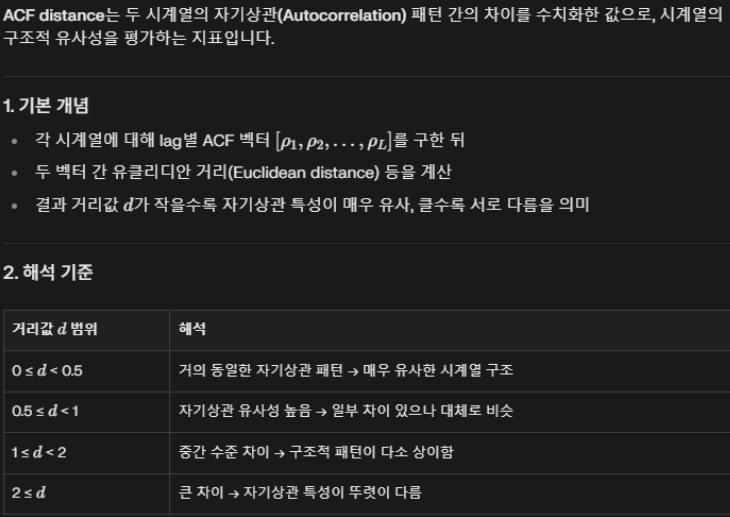

**2. 계층적 군집 분석을 위한 덴드로그램을 작성하시오.**

덴드로그램 작성 전, 계층적 군집분석의 적절한 군집의 수를 정하기 위해 실루엣 계수를 활용한다.

최적 군집 수: 2, 실루엣 계수: 0.766


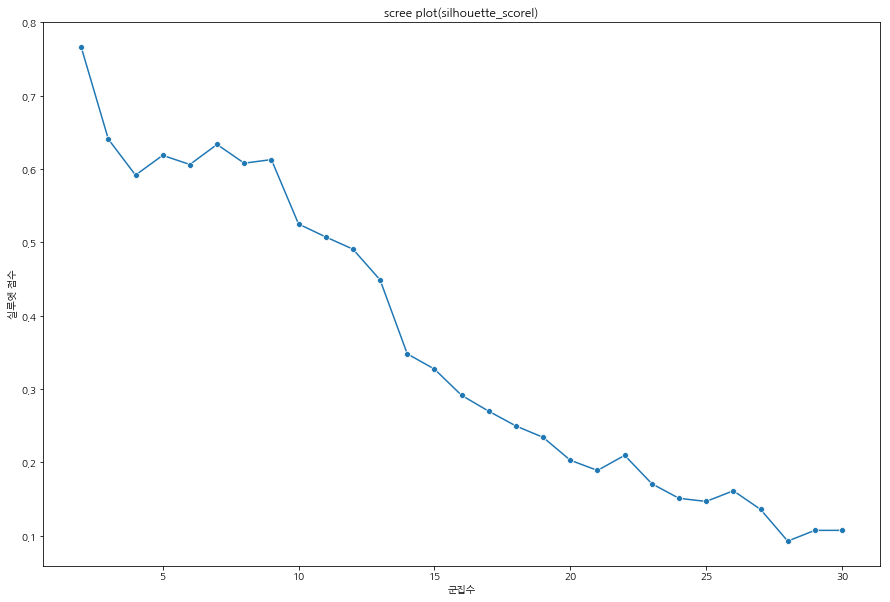

In [81]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

best_k = 2 #초기값
best_score = -1 #초기값
s_list = []
Z_tmp = linkage(dist_df, 'ward') #링키지 매트릭스


for k in range(2, len(countries)):
    labels = fcluster(Z_tmp, t=k, criterion='maxclust')
    score = silhouette_score(dist_df, labels, metric='precomputed')
    s_list.append(score)
    if score > best_score:
        best_score, best_k = score, k
print(f"최적 군집 수: {best_k}, 실루엣 계수: {best_score:.3f}")
plt.figure(figsize=(15, 10))
sns.lineplot(x=np.arange(2, len(s_list)+2), y=s_list, marker='o')
plt.title('scree plot(silhouette_scorel)')
plt.xlabel('군집수')
plt.ylabel('실루엣 점수')
plt.show()

군집이 2일 때, 실루엣 계수가 가장 높으므로 군집 수를 2로 분류

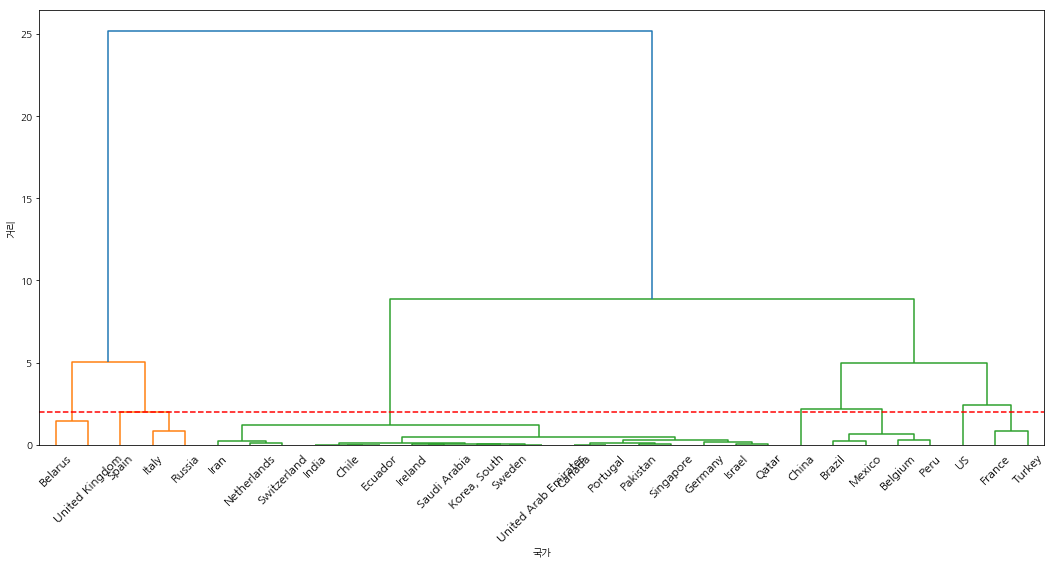

In [82]:
#군집화 결과 시각화
z = linkage(dist_df, 'ward') 

plt.figure(figsize=(18, 8))
dendrogram(z, labels=dist_df.index) #해당 거리값 기준 색상이 다른 군집들로 나눠줌
plt.axhline(y=2, ls='--', color='r')
plt.xlabel('국가')
plt.ylabel('거리')
plt.xticks(fontsize=12)
plt.show()

벨루스, 영국, 스페인, 이탈리아, 러시아와 나머지 국가로 2 군집의 계층적 군집이 분류되었다.
같은 군집에 속한 각 국가의 시계열 데이터의 유사도가 높다고 할 수 있겠다.


ACF distance를 이용해 국가별 시계열 간 유사도를 비교할 때는 차분을 통해   
정상성(stationarity)을 확보하는 것이 권장됩니다. 이유는 다음과 같습니다.

1. 비정상 시계열의 ACF 특성 왜곡
- 비정상(non-stationary) 시계열은 자기상관함수(ACF)가 느리게 감소하거나   
  일정하게 높은 값을 유지해, “패턴”이 실제보다 과장되거나 서로 다른 구조를   
  왜곡합니다.
  예컨대, 모든 국가 시계열이 공통의 장기 상승 추세를 가지면 ACF가 강하게 남아 
  유사도가 과도하게 높게 측정될 수 있습니다.
2. 정상성 확보의 효과
- 차분(differencing)을 통해 추세(trend)나 비정상 분산 문제를 제거하면, 시계열 고유의 주기성·계절성·단기 변동 패턴이 ACF에 반영됩니다.
이렇게 얻은 ACF 벡터로 거리(유클리디안, 코사인 등)를 계산하면, 국가별 동적 패턴 유사도를 더 정확히 비교할 수 있습니다.
3. 실무 관례

대부분의 시계열 유사도 비교 및 클러스터링 연구에서 “단위근(unit-root) 검정 → 필요 시 차분 → ACF/PACF 기반 거리 계산” 순서가 표준 워크플로우로 자리 잡고 있습니다.
특히 COVID-19 확진자처럼 명백한 상승 추세가 있는 시계열은 차분 없이는 ACF distance가 대부분 작은 값(즉, 모두 유사)만 내기 쉽습니다.
예외적 경우

모든 시계열이 이미 정상성을 만족한다거나, 비교 대상이 추세 자체일 때(예: 장기 성장률 비교)에는 차분을 생략할 수 있습니다.
하지만 일반적으로 “패턴(자기상관 구조) 유사도” 자체를 보고 싶으면 차분을 수행하는 편이 매우 유리합니다.

## 문제 3

슬통제약의 신약이 심장 질환 환자의 혈압을 낮출 수 있는지 검증하려고 한다. 표본으로 15명의 환자가 선택되었으며, 약을 복용하기 전과 복용한 후의 혈압을 측정하였다. 약이 혈압을 실제로 낮추는 것인지 검증하기 위해 유의수준 5%에서 부호 검정을 수행하시오.

In [55]:
dat = pd.read_csv('problem3.csv')

In [56]:
dat

,before_np,after_np
0,130,125
1,125,120
2,120,115
3,135,130
4,140,145
5,136,134
6,129,128
7,145,140
8,150,145
9,135,134


**1. 귀무가설과 대립가설을 수립하시오.**

-   귀무가설 : 약 복용 전후 혈압 차이는 없다. 
-   대립가설 : 약 복용 전후 혈압차이는 0보다 크다.(우측 검정) 

**2. 유효한 데이터 개수를 계산하시오.**

In [57]:
diff = dat['before_np'] - dat['after_np']
k = np.sum(diff > 0) #복용 후 혈압이 낮아진 경우
n = np.sum(diff != 0) #0이 아닌 개수
print(f"유효한 데이터수: {k}")

유효한 데이터수: 12


**부호검정을 수행하고 결과를 해석하시오.**

In [59]:
from scipy.stats import binom_test
p = binom_test(k, n, 0.5, alternative='greater')
print(f"p-value: {p:.4f}")

p-value: 0.0065


유의수준 5% 하에서 p-value가 0.0065로 낮으므로 귀무가설을 기각한다.  
따라서 신약은 혈압 강하에 효과가 있음이 통계적으로 유의하다.

## 문제 4

한 마을에서 사람들이 어떤 종류의 운동을 좋아하는지 조사했습니다. 이 마을에서는 세 가지 나이 그룹과 세 가지 운동 종류에 대해 조사를 했습니다. 나이 그룹은 다음과 같습니다.


|    -    | 축구 | 농구 | 테니스 |
|--------|------|------|--------|
| 청소년 | 15   | 25   | 10     |
| 청년   | 20   | 15   | 25     |
| 중장년 | 30   | 20   | 10     |

조사 결과를 통해 나이 그룹과 운동 종류 간의 관계가 있는지 분석하려고 합니다.

In [50]:
data = pd.DataFrame([[15, 25, 10],
                     [20, 15, 25],
                     [30, 20, 10]],
                    index=['청소년', '청년', '중장년'],
                    columns=['축구', '농구', '테니스'])

print(data)

     축구  농구  테니스
청소년  15  25   10
청년   20  15   25
중장년  30  20   10


**1. 귀무가설과 대립가설을 수립하시오.**

카이제곱 독립성 검정 문제이다.(한 모집단 내 여러수준 차이)
설명변수와 종속변수 모두 2그룹 이상의 명목변수이기 때문이다.  
유의수준 5% 하에서 검정을 실시하며 가설은 다음과 같다.

-   귀무가설 : 나이와 운동 선호도 간에는 관계가 없다.
-   대립가설 : 나이와 운동 선호도 간에는 관계가 있다.

**2. 독립일 경우의 기대빈도를 구하시오.**

In [52]:
from scipy.stats import chi2_contingency

stat, p, ddof, expected = chi2_contingency(data)

print(f"검정통계량: {stat:.3f}")
print(f"p-value: {p:.2f}", "(독립)" if p >=0.05 else "(연관)")

검정통계량: 16.570
p-value: 0.00 (연관)


In [54]:
# 독립이 아니다. 하지만 독립이라면,,,,
pd.DataFrame(expected, index=data.index, columns=data.columns)

,축구,농구,테니스
청소년,19.117647,17.647059,13.235294
청년,22.941176,21.176471,15.882353
중장년,22.941176,21.176471,15.882353


**3. 검정 결과를 해석하시오.**

유의수준 5% 하에서 카이제곱 독립성 검정 실시했을 때,  
p-value가 0.05보다 작아서 귀무가설을 기각한다.  
따라서  나이와 운동 선호도 간에는 관계가 있다.